In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [6]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [8]:
import os

dataset = "/kaggle/input/notebooks"

for root, dirs, files in os.walk(dataset):
    print(root)

In [9]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 639.3 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.2 MB/s eta 0:00:0000:0100:01


# DATASET PREPARATION

In [10]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    print(root)

/kaggle/input/datasets
/kaggle/input/datasets/manoj131310
/kaggle/input/datasets/manoj131310/final-formwork-dataset
/kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets
/kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/labels
/kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/labels/val
/kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/labels/test
/kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/labels/train
/kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images
/kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images/val
/kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images/test
/kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images/train


In [11]:
import shutil

shutil.copytree(
    "/kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets",
    "/kaggle/working/datasets"
)

'/kaggle/working/datasets'

In [12]:
import os

print("Train :", len(os.listdir("/kaggle/working/datasets/images/train")))
print("Val   :", len(os.listdir("/kaggle/working/datasets/images/val")))
print("Test  :", len(os.listdir("/kaggle/working/datasets/images/test")))

print("Train Labels:", len(os.listdir("/kaggle/working/datasets/labels/train")))
print("Val Labels  :", len(os.listdir("/kaggle/working/datasets/labels/val")))
print("Test Labels :", len(os.listdir("/kaggle/working/datasets/labels/test")))

Train : 354
Val   : 53
Test  : 53
Train Labels: 354
Val Labels  : 53
Test Labels : 53


In [13]:
with open("/kaggle/working/datasets/data.yaml", "r") as f:
    print(f.read())

path: /kaggle/working/datasets

train: images/train
val: images/val
test: images/test

names:
  0: Wood_formwork
  1: Plywood_formwork
  2: Steel_formwork
  3: Aluminium_formwork
  4: Plastic_formwork
  5: Coffor_formwork


# MODEL TRAINING 

In [14]:
from ultralytics import YOLO

# Load pretrained YOLO11s model
model = YOLO("yolo11s.pt")

# Train
results = model.train(
    data="/kaggle/working/datasets/data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    patience=30,
    workers=4,
    pretrained=True,
    project="Formwork_Final",
    name="YOLO11s_Final",
    plots=True,
    save=True,
    cache=True,
    amp=True,
    verbose=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/datasets/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s

# EVALUATION

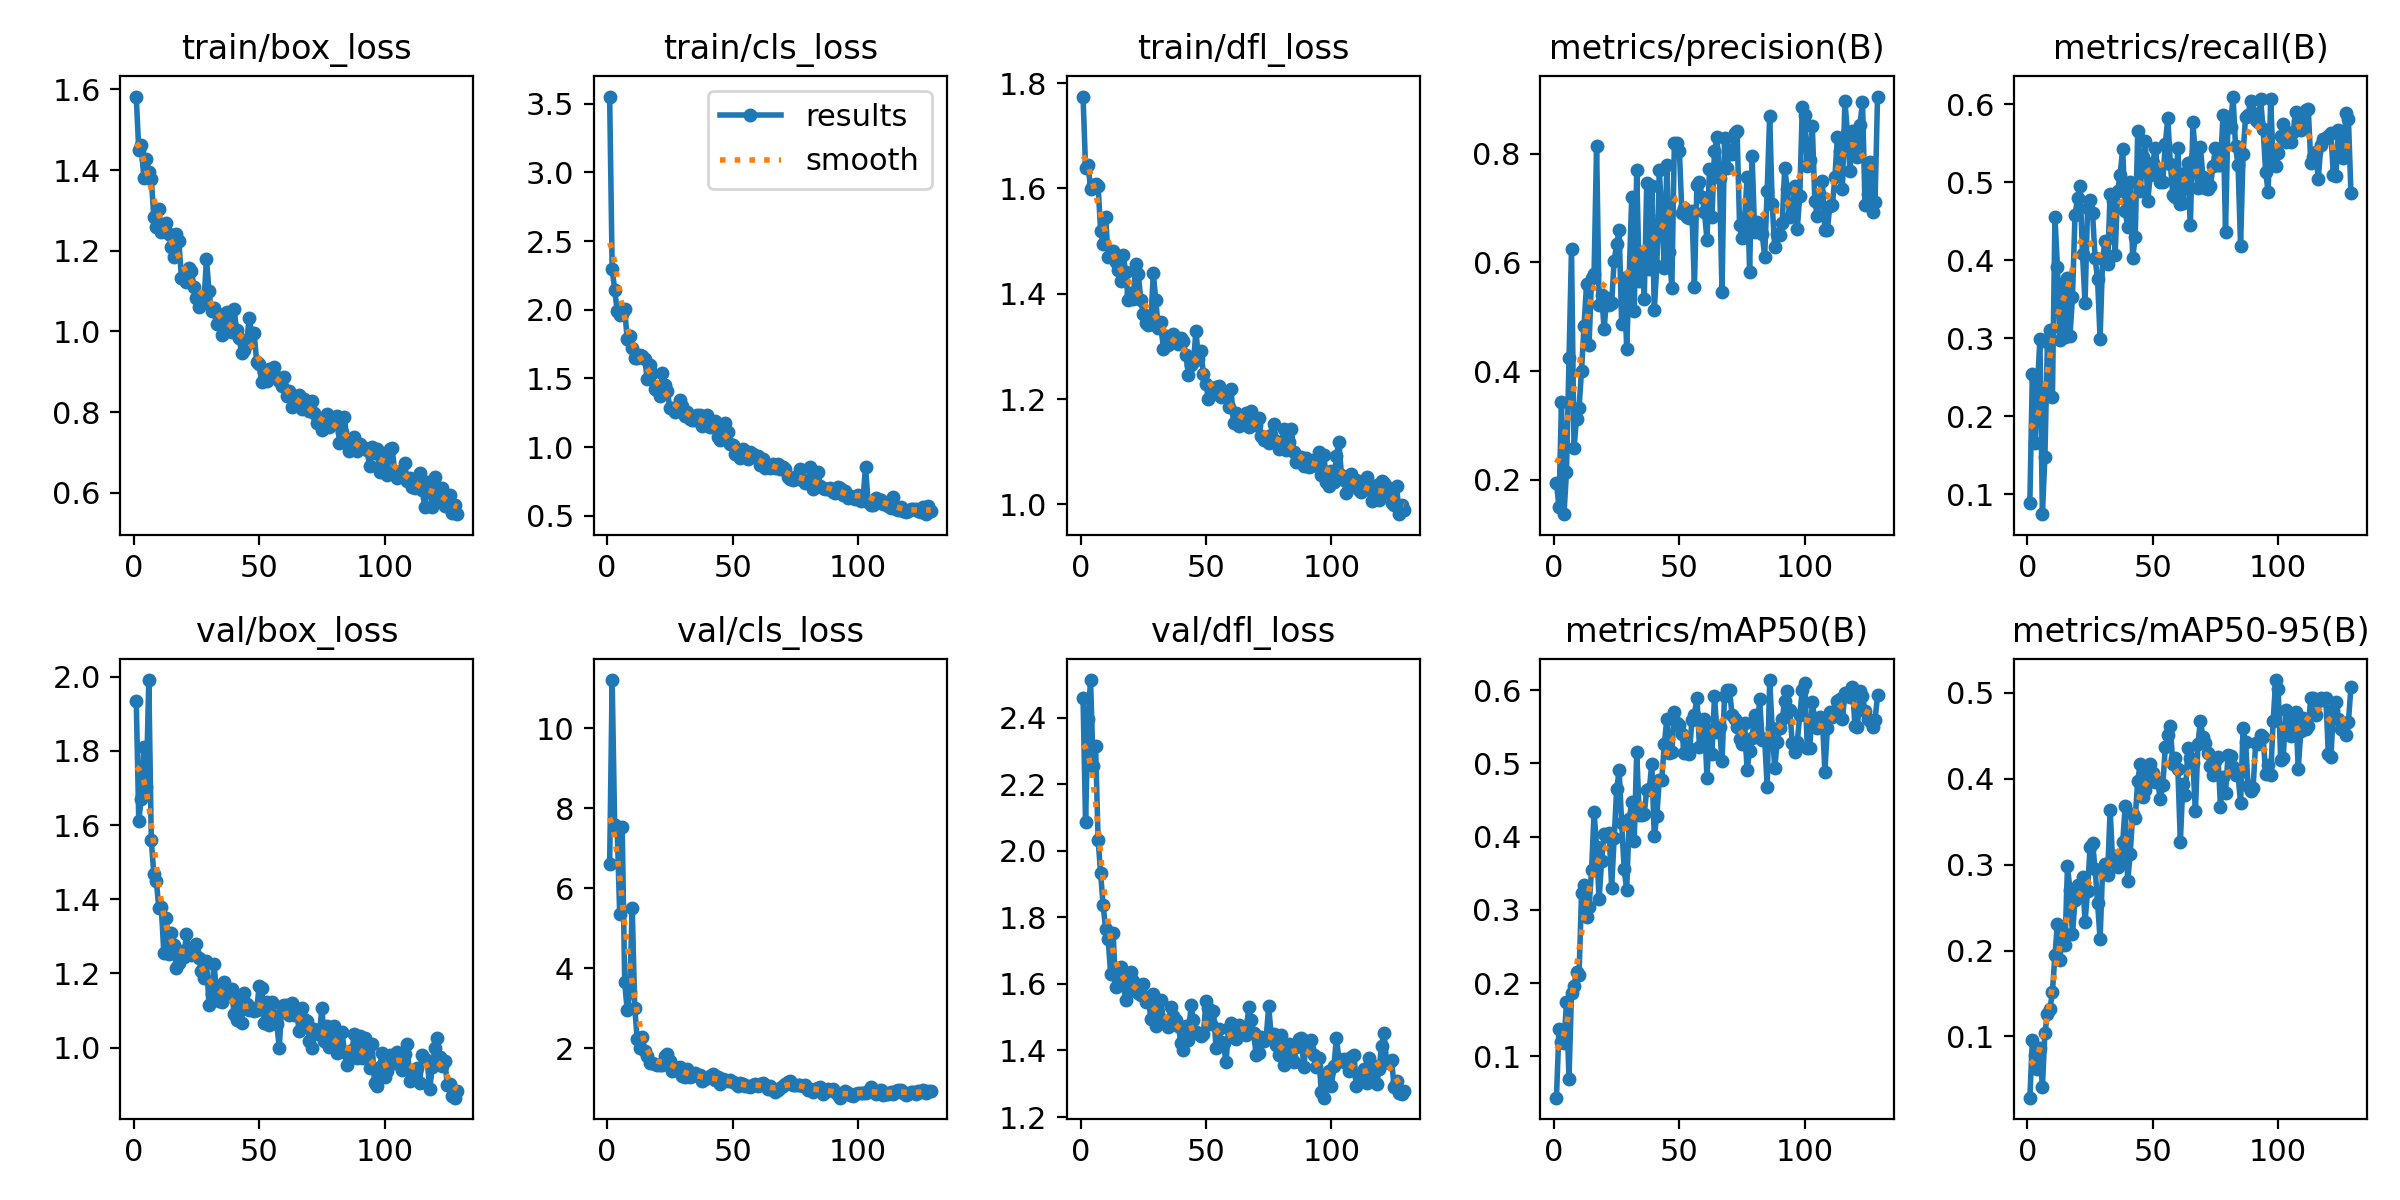

In [15]:
from IPython.display import Image

Image("/kaggle/working/runs/detect/Formwork_Final/YOLO11s_Final/results.png")

In [16]:
import os

for root, dirs, files in os.walk("/kaggle/working/runs"):
    print(root)
    for f in files:
        print("   ", f)

/kaggle/working/runs
/kaggle/working/runs/detect
/kaggle/working/runs/detect/Formwork_Final
/kaggle/working/runs/detect/Formwork_Final/YOLO11s_Final
    val_batch0_labels.jpg
    labels.jpg
    args.yaml
    confusion_matrix_normalized.png
    train_batch1.jpg
    BoxF1_curve.png
    confusion_matrix.png
    BoxPR_curve.png
    BoxR_curve.png
    results.csv
    BoxP_curve.png
    val_batch0_pred.jpg
    train_batch0.jpg
    val_batch1_pred.jpg
    train_batch2.jpg
    val_batch1_labels.jpg
    results.png
/kaggle/working/runs/detect/Formwork_Final/YOLO11s_Final/weights
    best.pt
    last.pt


In [23]:
model.predict(
    source="/kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images/test",
    conf=0.60,
    save=True,
    project="/kaggle/working/runs/detect",
    name="test_predictions"
)


image 1/53 /kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images/test/aluminum_020.jpg: 448x640 1 Aluminium_formwork, 12.6ms
image 2/53 /kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images/test/aluminum_023.jpg: 480x640 (no detections), 12.9ms
image 3/53 /kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images/test/aluminum_024.jpg: 640x640 1 Aluminium_formwork, 16.1ms
image 4/53 /kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images/test/aluminum_026.jpg: 512x640 1 Aluminium_formwork, 13.0ms
image 5/53 /kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images/test/aluminum_029.jpg: 544x640 1 Aluminium_formwork, 52.0ms
image 6/53 /kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images/test/aluminum_038.jpg: 448x640 2 Aluminium_formworks, 12.5ms
image 7/53 /kaggle/input/datasets/manoj131310/final-formwork-dataset/datasets/images/test/aluminum_041.jpg: 640x640 2 Aluminium_formw

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Wood_formwork', 1: 'Plywood_formwork', 2: 'Steel_formwork', 3: 'Aluminium_formwork', 4: 'Plastic_formwork', 5: 'Coffor_formwork'}
 obb: None
 orig_img: array([[[228, 212, 195],
         [222, 204, 187],
         [229, 209, 191],
         ...,
         [223, 212, 204],
         [127, 116, 112],
         [ 56,  47,  43]],
 
        [[228, 212, 195],
         [222, 204, 187],
         [229, 209, 191],
         ...,
         [223, 212, 204],
         [127, 116, 112],
         [ 56,  47,  43]],
 
        [[228, 212, 195],
         [222, 204, 187],
         [229, 209, 191],
         ...,
         [224, 213, 205],
         [127, 116, 112],
         [ 56,  47,  43]],
 
        ...,
 
        [[ 94, 118, 138],
         [ 80, 104, 124],
         [ 99, 123, 141],
         ...,
         [190, 202, 208],
         [190, 202, 208],
         [191, 203

In [20]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/Formwork_Final/YOLO11s_Final/weights/best.pt")

test_images = [
    "/kaggle/working/datasets/images/test/aluminum_023.jpg",
    "/kaggle/working/datasets/images/test/coffor_003.jpg",
    "/kaggle/working/datasets/images/test/plastic_045.jpg",
    "/kaggle/working/datasets/images/test/steel_012.jpg",
    "/kaggle/working/datasets/images/test/wood_080.jpg"
]

for img in test_images:
    model.predict(
        source=img,
        conf=0.70,
        save=True,
        save_conf=True,
        project="HighConfidence",
        name="TestPredictions",
        exist_ok=True
    )


image 1/1 /kaggle/working/datasets/images/test/aluminum_023.jpg: 480x640 (no detections), 52.8ms
Speed: 1.4ms preprocess, 52.8ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /kaggle/working/runs/detect/HighConfidence/TestPredictions

image 1/1 /kaggle/working/datasets/images/test/coffor_003.jpg: 352x640 1 Coffor_formwork, 53.2ms
Speed: 1.6ms preprocess, 53.2ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /kaggle/working/runs/detect/HighConfidence/TestPredictions

image 1/1 /kaggle/working/datasets/images/test/plastic_045.jpg: 512x640 1 Plastic_formwork, 53.5ms
Speed: 2.0ms preprocess, 53.5ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /kaggle/working/runs/detect/HighConfidence/TestPredictions

image 1/1 /kaggle/working/datasets/images/test/steel_012.jpg: 512x640 (no detections), 12.4ms
Speed: 2.1ms preprocess, 12.4ms inference, 0.5ms postprocess per image at shape (1, 3, 512

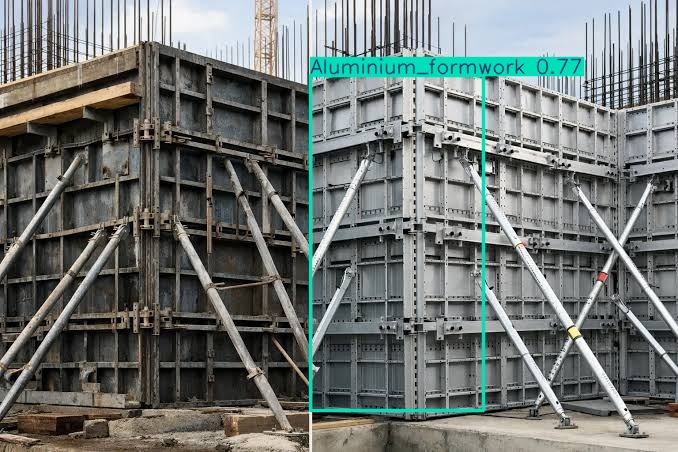

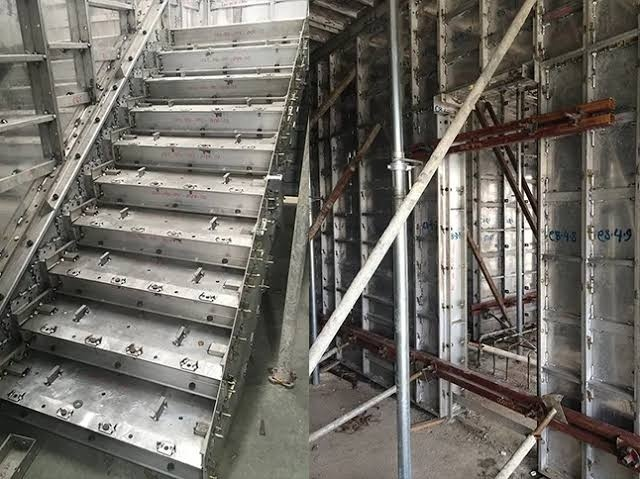

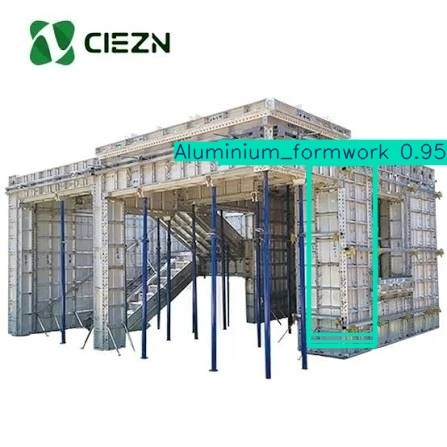

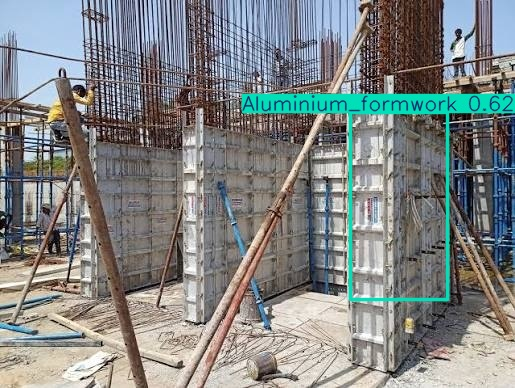

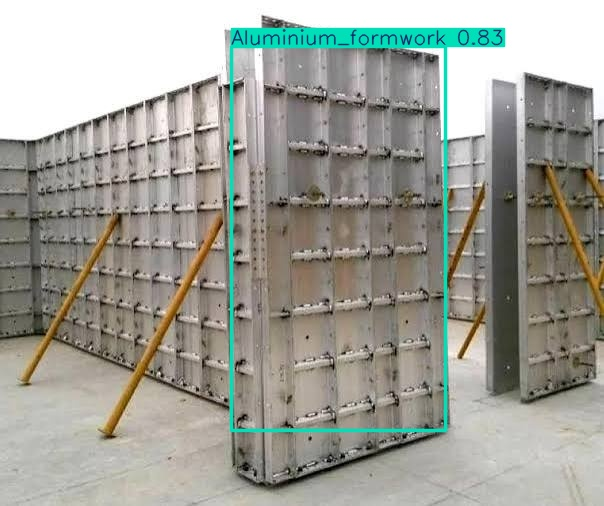

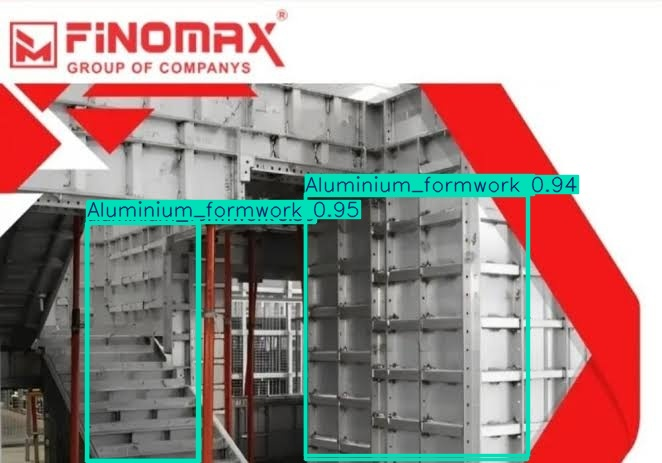

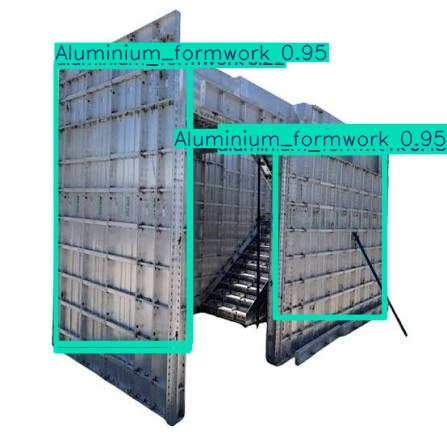

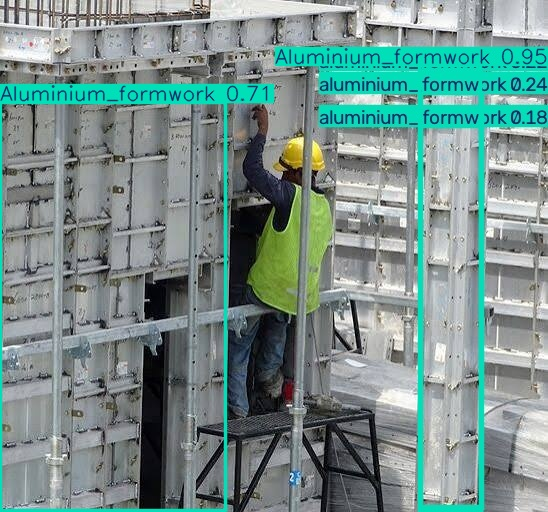

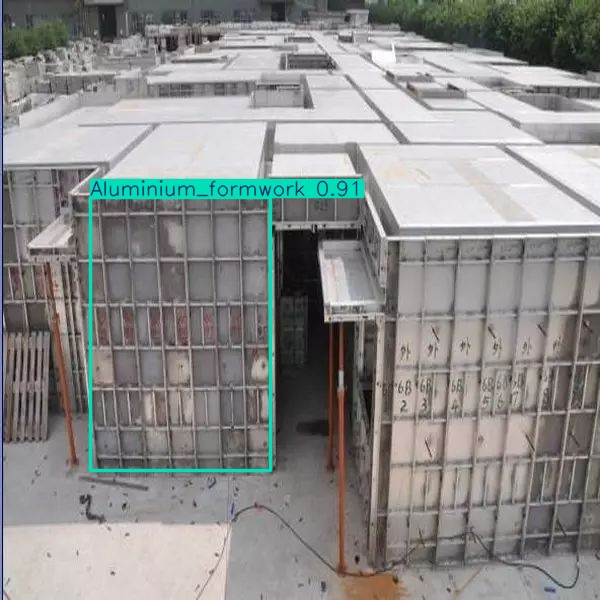

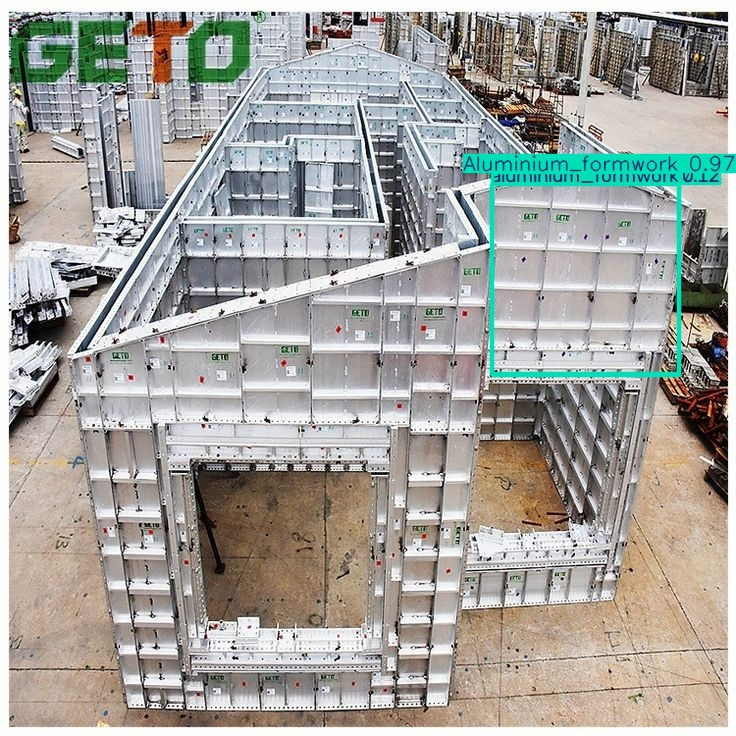

In [27]:
pred_dir = "/kaggle/working/runs/detect/test_predictions"

for f in sorted(os.listdir(pred_dir))[:10]:
    display(Image(os.path.join(pred_dir, f)))

# DEMO SECTION

In [36]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/Formwork_Final/YOLO11s_Final/weights/best.pt")

test_images = [
    "/kaggle/working/datasets/images/test/aluminum_024.jpg",
    "/kaggle/working/datasets/images/test/coffor_003.jpg",
    "/kaggle/working/datasets/images/test/plastic_045.jpg",
    "/kaggle/working/datasets/images/test/steel_012.jpg",
    "/kaggle/working/datasets/images/test/wood_080.jpg"
]

for img in test_images:
    model.predict(
        source=img,
        conf=0.70,
        save=True,
        save_conf=True,
        project="HighConfidence",
        name="TestPredictions",
        exist_ok=True
    )


image 1/1 /kaggle/working/datasets/images/test/aluminum_024.jpg: 640x640 1 Aluminium_formwork, 15.4ms
Speed: 2.4ms preprocess, 15.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/HighConfidence/TestPredictions

image 1/1 /kaggle/working/datasets/images/test/coffor_003.jpg: 352x640 1 Coffor_formwork, 11.2ms
Speed: 1.4ms preprocess, 11.2ms inference, 1.0ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /kaggle/working/runs/detect/HighConfidence/TestPredictions

image 1/1 /kaggle/working/datasets/images/test/plastic_045.jpg: 512x640 1 Plastic_formwork, 12.9ms
Speed: 1.9ms preprocess, 12.9ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /kaggle/working/runs/detect/HighConfidence/TestPredictions

image 1/1 /kaggle/working/datasets/images/test/steel_012.jpg: 512x640 (no detections), 12.4ms
Speed: 1.7ms preprocess, 12.4ms inference, 0.6ms postprocess per image at shape (1, 3

aluminum_024.jpg


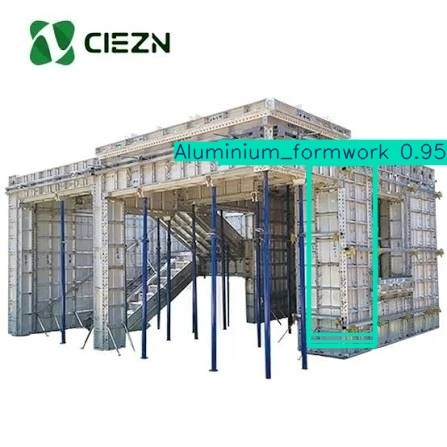

coffor_003.jpg


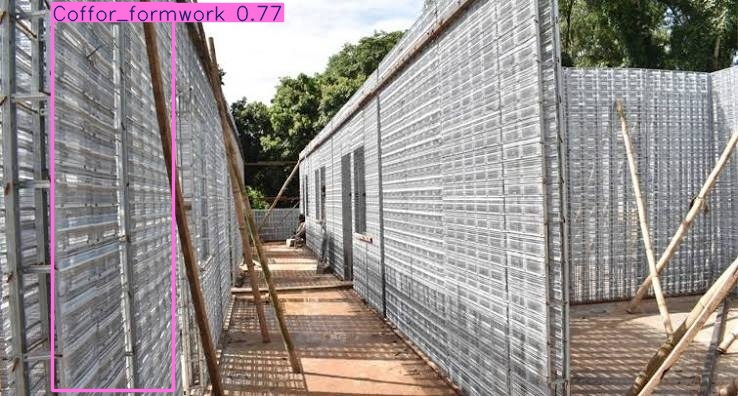

plastic_045.jpg


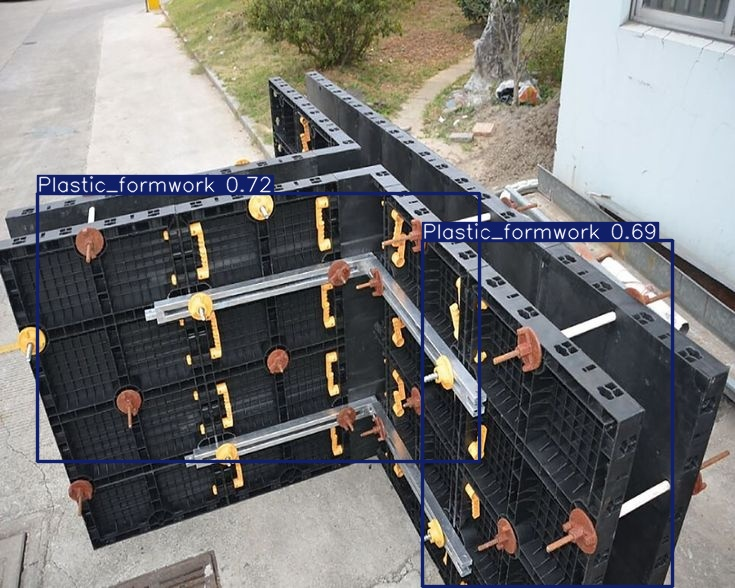

steel_012.jpg


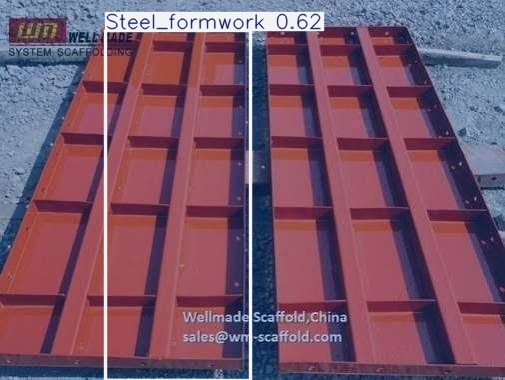

wood_080.jpg


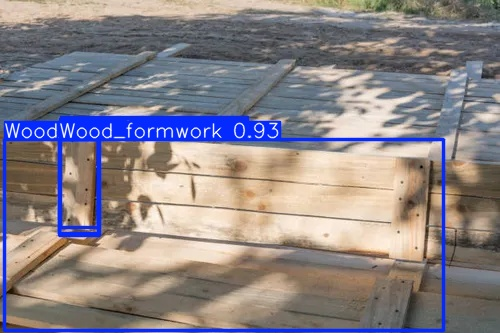

In [35]:
from IPython.display import Image, display
import os

pred_dir = "/kaggle/working/runs/detect/predict"

images = [
    "aluminum_024.jpg",
    "coffor_003.jpg",
    "plastic_045.jpg",
    "steel_012.jpg",
    "wood_080.jpg"
]

for img in images:
    path = os.path.join(pred_dir, img)
    if os.path.exists(path):
        print(img)
        display(Image(filename=path, width=700))
    else:
        print(f"{img} not found.")

In [40]:
def predict_image(model, img_path):
    return model.predict(img_path, conf=0.6)

# ***FINAL RESULT SUMMARY***

***Precision: 0.885***

***Recall:0.522***  

***mAP@50: 0.598***  

***mAP@50-95: 0.515***